In [1]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)


3.12.0 2.0.2 2.3.3 1.6.1


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 2729

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)


(297, 14) 0.461 (207, 13) (90, 13)


Student ID seed: `2729`.


## Part 1

### 1. Parent entropy

$$H = -\tfrac{6}{12}\log_2\tfrac{6}{12} - \tfrac{6}{12}\log_2\tfrac{6}{12} = -0.5\cdot(-1) - 0.5\cdot(-1) = \mathbf{1.000}$$

### 2. Information gain at the root

Formula: $IG = H(\text{parent}) - \sum_k \frac{n_k}{n} H(\text{child}_k)$.

| Feature | Branch 1 (yes/no) | Branch 0 (yes/no) | Weighted entropy | Gain |
|---|---:|---:|---:|---:|
| `age_55_plus` | 6 patients: 5 / 1 | 6 patients: 1 / 5 | 0.650 | 0.350 |
| `exercise_angina` | 4 patients: 4 / 0 | 8 patients: 2 / 6 | 0.541 | 0.459 |
| `male` | 6 patients: 3 / 3 | 6 patients: 3 / 3 | 1.000 | 0.000 |
| `high_bp` | 6 patients: 4 / 2 | 6 patients: 2 / 4 | 0.918 | 0.082 |

- `age_55_plus`: $H = -\tfrac56\log_2\tfrac56 - \tfrac16\log_2\tfrac16 = 0.219 + 0.431 = 0.650$. Weighted entropy: $\tfrac{6}{12}\cdot0.650 + \tfrac{6}{12}\cdot0.650 = 0.650$. Gain: $1 - 0.650 = 0.350$.
- `exercise_angina`: branch 1 is pure, so $H=0$. Branch 0: $H = -0.25\log_2 0.25 - 0.75\log_2 0.75 = 0.5 + 0.311 = 0.811$. Weighted entropy: $\tfrac{4}{12}\cdot0 + \tfrac{8}{12}\cdot0.811 = 0.541$. Gain: $1 - 0.541 = 0.459$.
- `male`: both branches have class counts 3 / 3, so each entropy is 1. Weighted entropy: 1. Gain: 0.
- `high_bp`: each branch has proportions 2/3 and 1/3, with $H = -\tfrac23\log_2\tfrac23 - \tfrac13\log_2\tfrac13 = 0.390 + 0.528 = 0.918$. Gain: $1 - 0.918 = 0.082$.

The selected root is `exercise_angina` (gain 0.459).

### 3. Gains within the impure branch

The `exercise_angina = 1` branch is pure (4 of 4 are diseased). The impure `exercise_angina = 0` branch contains 8 patients: 2 diseased and 6 without disease, so $H = -\tfrac28\log_2\tfrac28 - \tfrac68\log_2\tfrac68 = 0.811$.

| Feature | Branch 1 (yes/no) | Branch 0 (yes/no) | Weighted entropy | Gain |
|---|---:|---:|---:|---:|
| `age_55_plus` | 2 patients: 1 / 1 | 6 patients: 1 / 5 | $\tfrac28\cdot1 + \tfrac68\cdot0.650 = 0.738$ | 0.074 |
| `male` | 3 patients: 0 / 3 | 5 patients: 2 / 3 | $\tfrac38\cdot0 + \tfrac58\cdot0.971 = 0.607$ | 0.204 |
| `high_bp` | 3 patients: 1 / 2 | 5 patients: 1 / 4 | $\tfrac38\cdot0.918 + \tfrac58\cdot0.722 = 0.796$ | 0.016 |

The selected feature is `male` (gain 0.204). It had root gain 0.000. At the root, the male/female groups have identical class proportions, so sex alone gives no gain. Within the `exercise_angina = 0` subset, the male split separates a pure group of healthy patients; the tree evaluates features within each node, allowing a feature with no root gain to be useful below the root.


## Part 2


In [3]:
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    counts = np.bincount(y.astype(int))
    probabilities = counts[counts > 0] / len(y)
    return -np.sum(probabilities * np.log2(probabilities))

def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    right = ~left
    return entropy(y) - left.mean() * entropy(y[left]) - right.mean() * entropy(y[right])

def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    best = None
    best_gain = -np.inf

    for feature_index in range(X.shape[1]):
        values = np.unique(X[:, feature_index].astype(float))
        thresholds = values[:-1] + (values[1:] - values[:-1]) / 2

        for threshold in thresholds:
            left = X[:, feature_index] <= threshold
            if left.sum() < min_samples_leaf or (~left).sum() < min_samples_leaf:
                continue

            gain = information_gain(y, left)
            if gain > best_gain + 1e-12:
                best = (feature_index, float(threshold), float(gain))
                best_gain = gain

    return best

def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree of dicts: leaves store 'prediction'; splits store 'feature_index', 'threshold', 'left', and 'right'."""
    labels, counts = np.unique(y, return_counts=True)
    prediction = labels[np.argmax(counts)]

    if len(labels) == 1 or depth == max_depth:
        return {"prediction": prediction}

    split = best_split(X, y, min_samples_leaf)
    if split is None:
        return {"prediction": prediction}

    feature_index, threshold, _ = split
    left_mask = X[:, feature_index] <= threshold
    return {
        "feature_index": feature_index,
        "threshold": threshold,
        "left": build_tree(X[left_mask], y[left_mask], max_depth, min_samples_leaf, depth + 1),
        "right": build_tree(X[~left_mask], y[~left_mask], max_depth, min_samples_leaf, depth + 1),
    }

def predict_tree(tree, X):
    """Return one predicted label per row of X using a nested-dict tree."""
    predictions = []
    for row in X:
        node = tree
        while "prediction" not in node:
            if row[node["feature_index"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        predictions.append(node["prediction"])
    return np.asarray(predictions)


In [4]:
toy_X = np.array([
    [1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 0], [1, 1, 0, 1],
    [1, 0, 0, 1], [0, 0, 0, 0], [1, 0, 1, 0], [0, 0, 1, 0],
    [0, 0, 1, 0], [0, 0, 0, 1], [0, 0, 0, 1], [0, 0, 0, 0],
], dtype=int)
toy_y = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

assert np.isclose(entropy(toy_y), 1.000)
root_gains = [information_gain(toy_y, toy_X[:, j] == 1) for j in range(4)]
assert np.all(np.isclose(np.round(root_gains, 3), [0.350, 0.459, 0.000, 0.082]))

impure_branch = toy_X[:, 1] == 0
branch_gains = [
    information_gain(toy_y[impure_branch], toy_X[impure_branch, j] == 1)
    for j in [0, 2, 3]
]
assert np.all(np.isclose(np.round(branch_gains, 3), [0.074, 0.204, 0.016]))

root_split = best_split(toy_X, toy_y)
assert root_split is not None
assert root_split[0] == 1
assert np.isclose(root_split[1], 0.5)
assert np.isclose(root_split[2], root_gains[1])

assert best_split(toy_X, toy_y, min_samples_leaf=7) is None
assert best_split(np.ones((4, 2)), np.array([0, 0, 1, 1])) is None

full_tree = build_tree(toy_X, toy_y)
full_predictions = predict_tree(full_tree, toy_X)
assert np.isclose(np.mean(full_predictions == toy_y), 11 / 12)
assert full_predictions[5] == 0 and full_predictions[11] == 0

depth_zero_tree = build_tree(toy_X, toy_y, max_depth=0)
assert np.all(predict_tree(depth_zero_tree, toy_X) == 0)

depth_one_tree = build_tree(toy_X, toy_y, max_depth=1)
def count_splits(tree):
    if "prediction" in tree:
        return 0
    return 1 + count_splits(tree["left"]) + count_splits(tree["right"])
assert count_splits(depth_one_tree) == 1


In [5]:
from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(
    criterion="entropy", max_depth=1, random_state=SEED
).fit(X_train, y_train)
my_root_split = best_split(X_train, y_train)
assert my_root_split is not None

root_comparison = pd.DataFrame(
    [
        {
            "model": "sklearn",
            "feature": feature_names[ref.tree_.feature[0]],
            "threshold": ref.tree_.threshold[0],
        },
        {
            "model": "from scratch",
            "feature": feature_names[my_root_split[0]],
            "threshold": my_root_split[1],
        },
    ]
).set_index("model")
root_comparison


,feature,threshold
model,,
sklearn,thal,4.5
from scratch,thal,4.5


In [6]:
depths = [1, 2, 3, 4, 5, None]
scratch_trees = {}
sklearn_models = {}
agreement = {}

for depth in depths:
    scratch_trees[depth] = build_tree(X_train, y_train, max_depth=depth)
    sklearn_models[depth] = DecisionTreeClassifier(
        criterion="entropy", max_depth=depth, random_state=SEED
    ).fit(X_train, y_train)
    scratch_predictions = predict_tree(scratch_trees[depth], X_test)
    sklearn_predictions = sklearn_models[depth].predict(X_test)
    agreement[depth] = np.mean(scratch_predictions == sklearn_predictions)

agreement_table = pd.DataFrame(
    {"identical prediction fraction": [agreement[depth] for depth in depths]},
    index=pd.Index(depths, dtype=object),
)
agreement_table.index.name = "max_depth"
agreement_table


,identical prediction fraction
max_depth,
1,1.000000
2,1.000000
3,1.000000
4,1.000000
5,0.900000
None,0.977778


In [7]:
def first_tree_difference(custom_node, sklearn_node, X_node, y_node, model, path=()):
    sklearn_tree = model.tree_
    custom_leaf = "prediction" in custom_node
    sklearn_leaf = sklearn_tree.children_left[sklearn_node] == -1

    if custom_leaf and sklearn_leaf:
        return None

    custom_split = None if custom_leaf else (
        custom_node["feature_index"], custom_node["threshold"]
    )
    sklearn_split = None if sklearn_leaf else (
        sklearn_tree.feature[sklearn_node], sklearn_tree.threshold[sklearn_node]
    )

    if custom_split is None or sklearn_split is None:
        return path, custom_split, sklearn_split, X_node, y_node
    if custom_split[0] != sklearn_split[0] or not np.isclose(
        custom_split[1], sklearn_split[1], rtol=0, atol=1e-12
    ):
        return path, custom_split, sklearn_split, X_node, y_node

    left_mask = X_node[:, custom_split[0]] <= custom_split[1]
    if np.any(left_mask):
        difference = first_tree_difference(
            custom_node["left"], sklearn_tree.children_left[sklearn_node],
            X_node[left_mask], y_node[left_mask], model, path + ("left",)
        )
        if difference is not None:
            return difference

    right_mask = ~left_mask
    if np.any(right_mask):
        return first_tree_difference(
            custom_node["right"], sklearn_tree.children_right[sklearn_node],
            X_node[right_mask], y_node[right_mask], model, path + ("right",)
        )
    return None

for depth in depths:
    if agreement[depth] < 1.0:
        difference = first_tree_difference(
            scratch_trees[depth], 0, X_train, y_train, sklearn_models[depth]
        )
        print(f"max_depth={depth}; agreement={agreement[depth]:.3f}")
        if difference is None:
            print("No structural split difference found.")
            continue

        path, custom_split, sklearn_split, X_node, y_node = difference
        print(f"first differing path: {path or 'root'}")
        for label, split in [("from scratch", custom_split), ("sklearn", sklearn_split)]:
            if split is None:
                print(f"{label}: leaf; gain not applicable")
            else:
                feature_index, threshold = split
                gain = information_gain(y_node, X_node[:, feature_index] <= threshold)
                print(
                    f"{label}: {feature_names[feature_index]} <= {threshold:.12g}; "
                    f"gain={gain:.12g}"
                )


max_depth=5; agreement=0.900
first differing path: ('left', 'right', 'right', 'right')
from scratch: age <= 63.5; gain=0.311278124459
sklearn: thalach <= 143.5; gain=0.311278124459
max_depth=None; agreement=0.978
first differing path: ('left', 'right', 'left', 'left', 'right', 'right')
from scratch: age <= 42.5; gain=0.721928094887
sklearn: cp <= 2.5; gain=0.721928094887


In [8]:
for depth in depths:
    if agreement[depth] == 1.0:
        continue

    difference = first_tree_difference(
        scratch_trees[depth], 0, X_train, y_train, sklearn_models[depth]
    )
    if difference is None:
        continue

    path, custom_split, sklearn_split, X_node, y_node = difference
    custom_feature, custom_threshold = custom_split
    sklearn_feature, sklearn_threshold = sklearn_split
    custom_gain = information_gain(
        y_node, X_node[:, custom_feature] <= custom_threshold
    )
    sklearn_gain = information_gain(
        y_node, X_node[:, sklearn_feature] <= sklearn_threshold
    )

    print(f"max_depth={depth}; first differing path={path or 'root'}; rows={len(y_node)}")
    display(pd.DataFrame(X_node, columns=feature_names).assign(disease=y_node))
    print(
        f"from scratch: {feature_names[custom_feature]} <= {custom_threshold:.12g}; "
        f"gain={custom_gain:.12g}"
    )
    print(
        f"sklearn: {feature_names[sklearn_feature]} <= {sklearn_threshold:.12g}; "
        f"gain={sklearn_gain:.12g}"
    )
    print(f"gains equal (atol=1e-12): {np.isclose(custom_gain, sklearn_gain, rtol=0, atol=1e-12)}")
    if custom_feature == sklearn_feature:
        print(f"sklearn threshold - custom threshold: {sklearn_threshold - custom_threshold:.12g}")
    else:
        print("threshold difference: not directly comparable (different features)")
    print(f"X_train dtype: {X_train.dtype}; sklearn stored-threshold dtype: {sklearn_models[depth].tree_.threshold.dtype}")


max_depth=5; first differing path=('left', 'right', 'right', 'right'); rows=8


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
0,63.0,0.0,4.0,124.0,197.0,0.0,0.0,136.0,1.0,0.0,2.0,0.0,3.0,1
1,59.0,0.0,4.0,174.0,249.0,0.0,0.0,143.0,1.0,0.0,2.0,0.0,3.0,1
2,66.0,1.0,4.0,112.0,212.0,0.0,2.0,132.0,1.0,0.1,1.0,1.0,3.0,1
3,63.0,0.0,4.0,108.0,269.0,0.0,0.0,169.0,1.0,1.8,2.0,2.0,3.0,1
4,64.0,1.0,1.0,110.0,211.0,0.0,2.0,144.0,1.0,1.8,2.0,0.0,3.0,0
5,55.0,0.0,4.0,180.0,327.0,0.0,1.0,117.0,1.0,3.4,2.0,0.0,3.0,1
6,64.0,0.0,4.0,180.0,325.0,0.0,0.0,154.0,1.0,0.0,1.0,0.0,3.0,0
7,77.0,1.0,4.0,125.0,304.0,0.0,2.0,162.0,1.0,0.0,1.0,3.0,3.0,1


from scratch: age <= 63.5; gain=0.311278124459
sklearn: thalach <= 143.5; gain=0.311278124459
gains equal (atol=1e-12): True
threshold difference: not directly comparable (different features)
X_train dtype: float64; sklearn stored-threshold dtype: float64
max_depth=None; first differing path=('left', 'right', 'left', 'left', 'right', 'right'); rows=5


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
0,44.0,1.0,4.0,112.0,290.0,0.0,2.0,153.0,0.0,0.0,1.0,1.0,3.0,1
1,46.0,1.0,3.0,150.0,231.0,0.0,0.0,147.0,0.0,3.6,2.0,0.0,3.0,1
2,41.0,1.0,2.0,110.0,235.0,0.0,0.0,153.0,0.0,0.0,1.0,0.0,3.0,0
3,47.0,1.0,3.0,108.0,243.0,0.0,0.0,152.0,0.0,0.0,1.0,0.0,3.0,1
4,47.0,1.0,4.0,110.0,275.0,0.0,2.0,118.0,1.0,1.0,2.0,1.0,3.0,1


from scratch: age <= 42.5; gain=0.721928094887
sklearn: cp <= 2.5; gain=0.721928094887
gains equal (atol=1e-12): True
threshold difference: not directly comparable (different features)
X_train dtype: float64; sklearn stored-threshold dtype: float64


## Part 3


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_results = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy", max_depth=depth, random_state=SEED
    )
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        return_estimator=True,
    )
    # NumPy's std defaults to ddof=0, the population standard deviation across folds.
    depth_results.append(
        {
            "depth": depth,
            "leaves": np.mean([est.get_n_leaves() for est in scores["estimator"]]),
            "train_acc_mean": scores["train_score"].mean(),
            "cv_acc_mean": scores["test_score"].mean(),
            "cv_acc_std": scores["test_score"].std(),
        }
    )

depth_table = pd.DataFrame(depth_results)
depth_table["depth"] = pd.Series(depths, dtype=object)
depth_table.round(3)


,depth,leaves,train_acc_mean,cv_acc_mean,cv_acc_std
0,1,2.0,0.780,0.744,0.044
1,2,4.0,0.801,0.744,0.023
2,3,7.6,0.859,0.787,0.033
3,4,12.8,0.895,0.734,0.039
4,5,18.2,0.938,0.720,0.027
5,6,22.8,0.975,0.724,0.027
6,8,25.6,0.996,0.724,0.039
7,10,26.4,1.000,0.729,0.031
8,None,26.4,1.000,0.729,0.031


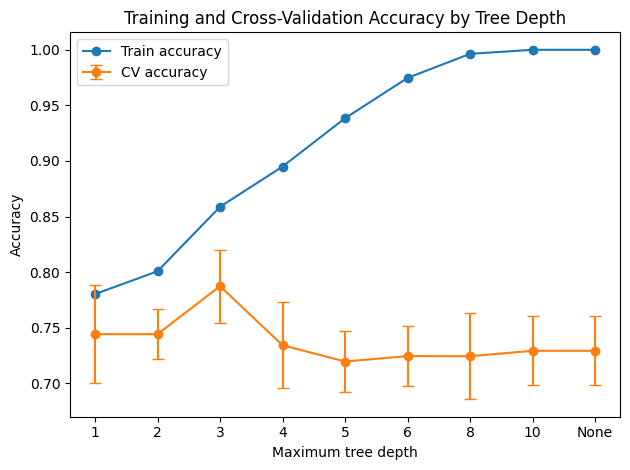

In [10]:
import matplotlib.pyplot as plt

x_positions = np.arange(len(depth_table))
depth_labels = depth_table["depth"].map(str)

fig, ax = plt.subplots()
ax.plot(x_positions, depth_table["train_acc_mean"], marker="o", label="Train accuracy")
ax.errorbar(
    x_positions,
    depth_table["cv_acc_mean"],
    yerr=depth_table["cv_acc_std"],
    marker="o",
    capsize=4,
    label="CV accuracy",
)
ax.set_xticks(x_positions, depth_labels)
ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Accuracy")
ax.set_title("Training and Cross-Validation Accuracy by Tree Depth")
ax.legend()
fig.tight_layout()
plt.show()


In [11]:
best_row_index = depth_table["cv_acc_mean"].idxmax()
selection_threshold = (
    depth_table.loc[best_row_index, "cv_acc_mean"]
    - depth_table.loc[best_row_index, "cv_acc_std"]
)
candidate_rows = depth_table[depth_table["cv_acc_mean"] >= selection_threshold]
selected_index = candidate_rows.index[0]
selected_depth = depth_table.loc[selected_index, "depth"]

print(f"Threshold: {selection_threshold:.3f}")
print("Candidates:")
display(candidate_rows[["depth", "cv_acc_mean", "cv_acc_std"]].round(3))
print(f"Selected depth: {selected_depth}")

neighbor_indices = [
    index for index in [selected_index - 1, selected_index, selected_index + 1]
    if index in depth_table.index
]
neighbors_table = depth_table.loc[
    neighbor_indices, ["depth", "cv_acc_mean", "cv_acc_std"]
].copy()
neighbors_table["selected"] = neighbors_table.index == selected_index
neighbors_table.round(3)


Threshold: 0.754
Candidates:


,depth,cv_acc_mean,cv_acc_std
2,3,0.787,0.033


Selected depth: 3


,depth,cv_acc_mean,cv_acc_std,selected
1,2,0.744,0.023,False
2,3,0.787,0.033,True
3,4,0.734,0.039,False


### Min-samples-leaf sweep


In [12]:
min_samples_leaf_values = [1, 2, 5, 10, 20, 40]
leaf_results = []

for min_samples_leaf in min_samples_leaf_values:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        random_state=SEED,
    )
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        return_estimator=True,
    )
    # NumPy's std defaults to ddof=0, the population standard deviation across folds.
    leaf_results.append(
        {
            "min_samples_leaf": min_samples_leaf,
            "leaves": np.mean([est.get_n_leaves() for est in scores["estimator"]]),
            "train_acc_mean": scores["train_score"].mean(),
            "cv_acc_mean": scores["test_score"].mean(),
            "cv_acc_std": scores["test_score"].std(),
        }
    )

leaf_table = pd.DataFrame(leaf_results)
leaf_table.round(3)


,min_samples_leaf,leaves,train_acc_mean,cv_acc_mean,cv_acc_std
0,1,26.4,1.000,0.729,0.031
1,2,23.8,0.965,0.705,0.032
2,5,15.8,0.902,0.734,0.044
3,10,10.2,0.854,0.758,0.065
4,20,6.2,0.796,0.744,0.044
5,40,3.2,0.780,0.744,0.044


In [13]:
from sklearn.metrics import accuracy_score

chosen_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=selected_depth, random_state=SEED
).fit(X_train, y_train)
test_predictions = chosen_tree.predict(X_test)
p = accuracy_score(y_test, test_predictions)
n = len(y_test)
standard_error = np.sqrt(p * (1 - p) / n)
print(f"max_depth={selected_depth}; p={p:.3f}; n={n}; standard error={standard_error:.3f}")


max_depth=3; p=0.733; n=90; standard error=0.047


## Part 4


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

part4_models = {
    "Chosen tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=selected_depth, random_state=SEED
    ),
    "Unlimited-depth tree": DecisionTreeClassifier(
        criterion="entropy", max_depth=None, random_state=SEED
    ),
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000)
    ),
}

part4_cv_rows = []
for model_name, model in part4_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=("accuracy", "f1"),
    )
    part4_cv_rows.append(
        {
            "model": model_name,
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_mean": scores["test_f1"].mean(),
        }
    )

part4_cv_table = pd.DataFrame(part4_cv_rows)
part4_cv_table.round(3)


,model,accuracy_mean,accuracy_std,f1_mean
0,Chosen tree,0.787,0.033,0.743
1,Unlimited-depth tree,0.729,0.031,0.698
2,Logistic regression,0.845,0.059,0.823


In [15]:
tree_unscaled = DecisionTreeClassifier(
    criterion="entropy", max_depth=selected_depth, random_state=SEED
).fit(X_train, y_train)

scaler = StandardScaler().fit(X_train)
tree_scaled = DecisionTreeClassifier(
    criterion="entropy", max_depth=selected_depth, random_state=SEED
).fit(scaler.transform(X_train), y_train)

predictions_unscaled = tree_unscaled.predict(X_test)
predictions_scaled = tree_scaled.predict(scaler.transform(X_test))
print(np.mean(predictions_unscaled == predictions_scaled))


1.0


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

holdout_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=selected_depth, random_state=SEED
).fit(X_train, y_train)
holdout_logreg = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=5000)
).fit(X_train, y_train)

tree_predictions = holdout_tree.predict(X_test)
logreg_predictions = holdout_logreg.predict(X_test)

for model_name, predictions in [
    ("Chosen tree", tree_predictions),
    ("Logistic regression", logreg_predictions),
]:
    print(f"{model_name}: accuracy={accuracy_score(y_test, predictions):.3f}; "
          f"F1={f1_score(y_test, predictions):.3f}")
    matrix = pd.DataFrame(
        confusion_matrix(y_test, predictions, labels=[0, 1]),
        index=pd.Index([0, 1], name="True class"),
        columns=pd.Index([0, 1], name="Predicted class"),
    )
    display(matrix)


Chosen tree: accuracy=0.733; F1=0.684


Predicted class,0,1
True class,,
0,40,8
1,16,26


Logistic regression: accuracy=0.811; F1=0.779


Predicted class,0,1
True class,,
0,43,5
1,12,30
